In [3]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# Datos de ejemplo
X = np.array([
    [3, 6],
    [5, 7],
    [8, 1],
    [9, 1],
    [10, 4],
    [11, 5]
])

In [4]:
# 1. Matriz de distancias
dist_matrix = pdist(X, metric='euclidean')
dist_square = squareform(dist_matrix)

print("Matriz de distancias:")
print(dist_square)


Matriz de distancias:
[[0.         2.23606798 7.07106781 7.81024968 7.28010989 8.06225775]
 [2.23606798 0.         6.70820393 7.21110255 5.83095189 6.32455532]
 [7.07106781 6.70820393 0.         1.         3.60555128 5.        ]
 [7.81024968 7.21110255 1.         0.         3.16227766 4.47213595]
 [7.28010989 5.83095189 3.60555128 3.16227766 0.         1.41421356]
 [8.06225775 6.32455532 5.         4.47213595 1.41421356 0.        ]]


In [5]:
# 2. Clustering jerárquico (enlace completo)
Z = linkage(dist_matrix, method='complete')


In [6]:
# 3. Cortar por distancia
distancia_corte = 3.0   # <<< AQUÍ defines la distancia máxima
clusters = fcluster(Z, t=distancia_corte, criterion='distance')

print("\nClusters asignados:")
print(clusters)



Clusters asignados:
[1 1 2 2 3 3]


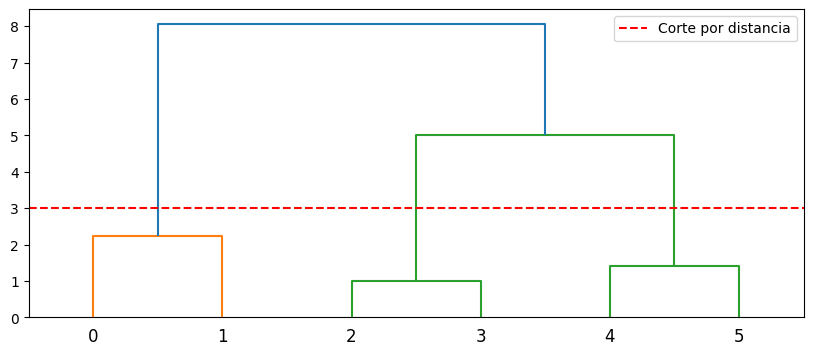

In [7]:
# 4. Graficar dendrograma con línea de corte
plt.figure(figsize=(10, 4))
dn = dendrogram(Z)
plt.axhline(y=distancia_corte, color='red', linestyle='--', label='Corte por distancia')
plt.legend()
plt.show()

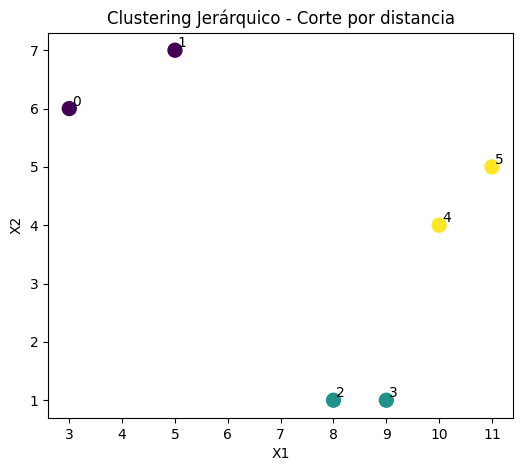

In [9]:
# 5. Gráfico de dispersión con clusters asignados
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=100)
plt.title("Clustering Jerárquico - Corte por distancia")
plt.xlabel("X1")
plt.ylabel("X2")

# Añadir las etiquetas para identificar los puntos (opcional)
for i, point in enumerate(X):
    plt.text(point[0]+0.05, point[1]+0.05, str(i))

plt.show()